In [ ]:
import os
import sys
import cv2
import numpy as np
import pandas as pd
import open3d as o3d
import matplotlib.pyplot as plt
from pathlib import Path

# Fix relative imports
candidate_roots = [d for d in Path.cwd().parents if d.name == "multimodal-pothole-detection"]
if len(candidate_roots) == 0:
    if Path.cwd().name == "multimodal-pothole-detection":
        code_root = Path.cwd()
    else:
        raise RuntimeError("Notebook needs to be run within the multimodal-pothole-detection project.")
else:
    code_root = candidate_roots[-1]

dataset_root = code_root / "data" / "raw" / "PothRGDB" / "PUBLIC POTHOLE DATASET"
manifest_path = code_root / "data" / "interim" / "pothrgbd_manifest.csv"

scripts_root = code_root / "src" / "scripts"
if str(scripts_root) not in sys.path:
    sys.path.insert(0, str(scripts_root))

from pothole_geometry import load_yolo_mask

In [ ]:
import sys
import pandas as pd
from pathlib import Path

# 1. Resolve Project Paths (robust to running from notebook or root)
candidate_roots = [d for d in Path.cwd().parents if d.name == "multimodal-pothole-detection"]
if len(candidate_roots) == 0:
    if Path.cwd().name == "multimodal-pothole-detection":
        code_root = Path.cwd()
    else:
        raise RuntimeError("Are you running this outside the multimodal-pothole-detection project?")
else:
    code_root = candidate_roots[-1]

dataset_root = code_root / "data" / "raw" / "PothRGDB" / "PUBLIC POTHOLE DATASET"
manifest_path = code_root / "data" / "interim" / "pothrgbd_manifest.csv"

# Add scripts to path to import our tested geometry helpers
scripts_root = code_root / "src" / "scripts"
if str(scripts_root) not in sys.path:
    sys.path.insert(0, str(scripts_root))

from pothole_geometry import load_yolo_mask

# 2. Load Manifest and filter only valid samples
manifest = pd.read_csv(manifest_path)
valid_samples = manifest[manifest["status"] == "ok"].reset_index(drop=True)

# ---> CHANGE THIS INDEX TO LOAD DIFFERENT SAMPLES <---
sample_idx = 500
row = valid_samples.iloc[sample_idx]
sample_id = row["sample_id"]
print(f"Loading Sample {sample_idx} -> ID: {sample_id}")

# Build dynamic paths
rgb_path = str(dataset_root / row["image_path"])
depth_path = str(dataset_root / row["depth_path"])
mask_path = Path(dataset_root / row["label_path"])

# 3. Load RGB image
rgb = cv2.imread(rgb_path)
if rgb is not None:
    rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)

# 4. Load depth map (CRITICAL: MUST use .npy to preserve physical mm scale!)
depth = np.load(depth_path) if depth_path.endswith(".npy") else None

# 5. Load YOLO mask using our tested Polygon Segmentation parser
mask = None
if depth is not None:
    mask = load_yolo_mask(mask_path, image_shape=depth.shape)

Loading Sample 500 -> ID: 20250305_062157


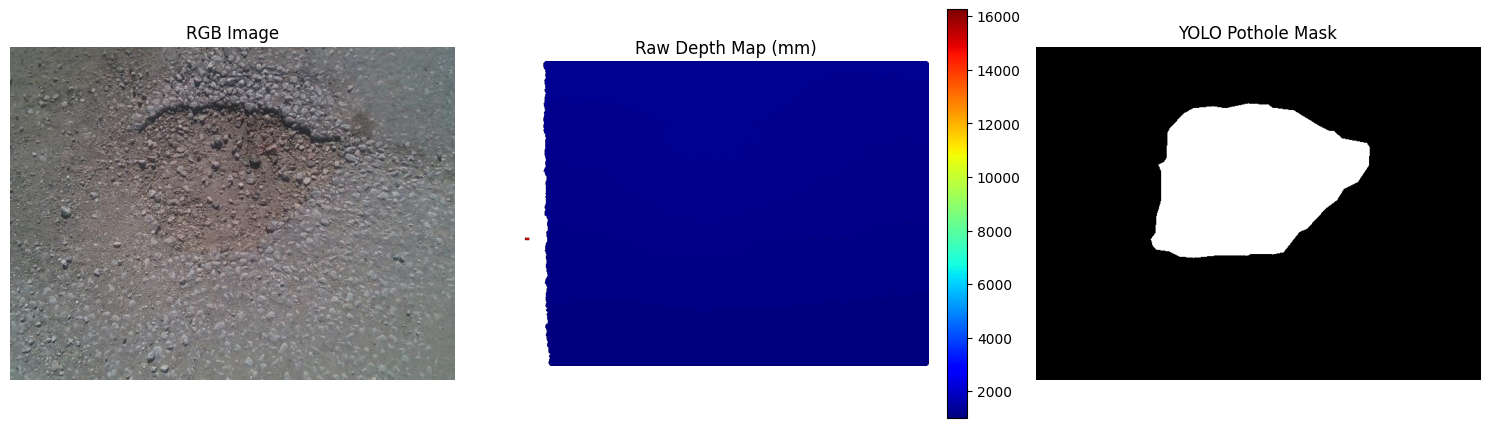

In [3]:
# Better visualization for raw depth maps (ignoring sensor 0s and highlighting variations)
if depth is not None:
    depth_vis = depth.astype(np.float32)
    depth_vis[depth_vis == 0] = np.nan  # Ignores sensor failures so they don't crush the color scale

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(rgb)
    axes[0].set_title("RGB Image")
    axes[0].axis('off')
    
    im1 = axes[1].imshow(depth_vis, cmap='jet')
    axes[1].set_title("Raw Depth Map (mm)")
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    axes[2].imshow(mask, cmap='gray')
    axes[2].set_title("YOLO Pothole Mask")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

In [4]:
# Camera parameters approximated for Intel RealSense D415 (per methodology)
# These values form the "Nominal" scenario of our Sensitivity Protocol
fx, fy = 460.0, 460.0

if rgb is not None:
    cx, cy = rgb.shape[1] / 2.0, rgb.shape[0] / 2.0
else:
    cx, cy = 320.0, 240.0

In [5]:
# Configuration parameter to include surrounding street context
surrounding_margin_px = 30  # Set to 0 for strictly the pothole, or >0 (e.g., 30) to include surrounding street

# Convert to 3D Point Cloud: Vectorized Two-Stage Extraction & Flat Plane Assumption
points = []
colors = []

if depth is not None and mask is not None and rgb is not None:
    # 1. Flat Plane Assumption: Estimate road surface using valid depth outside the REAL pothole
    road_mask = (mask == 0) & (depth > 0)
    road_surface_depth = np.median(depth[road_mask])
    print(f"Flat Plane Assumption: Road surface estimated at Z = {road_surface_depth:.2f} mm")

    # 2. Extract Pothole Region (with optional expanded context via dilation)
    base_mask_bin = (mask > 0).astype(np.uint8)
    if surrounding_margin_px > 0:
        kernel_size = surrounding_margin_px * 2 + 1
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
        expanded_mask = cv2.dilate(base_mask_bin, kernel, iterations=1)
        pothole_mask = (expanded_mask > 0) & (depth > 0)
    else:
        pothole_mask = (base_mask_bin > 0) & (depth > 0)

    # 3. Vectorized Projection (Replaces slow nested for-loops)
    h, w = depth.shape
    u, v = np.meshgrid(np.arange(w), np.arange(h))
    
    u_valid = u[pothole_mask]
    v_valid = v[pothole_mask]
    z_true = depth[pothole_mask].astype(np.float32)
    
    # Unproject to real-world X, Y coordinates
    X = (u_valid - cx) * z_true / fx
    Y = (v_valid - cy) * z_true / fy
    
    # Normalize Z so the road surface is 0, and the pothole goes deep (positive values)
    Z_norm = z_true - road_surface_depth

    print(f"Z true vs z norm stats: min={z_true.min():.2f}, max={z_true.max():.2f}, mean={z_true.mean():.2f} | "
          f"Z norm stats: min={Z_norm.min():.2f}, max={Z_norm.max():.2f}, mean={Z_norm.mean():.2f}")

    points = np.stack((X, Y, Z_norm), axis=-1)
    colors = rgb[pothole_mask] / 255.0
else:
    print("Files not loaded. Please provide valid paths.")
    points = np.array([])
    colors = np.array([])

Flat Plane Assumption: Road surface estimated at Z = 1114.00 mm
Z true vs z norm stats: min=1091.00, max=1267.00, mean=1191.43 | Z norm stats: min=-23.00, max=153.00, mean=77.43


In [12]:
# Create Point Cloud (Open3D)

import open3d as o3d

pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(points)
pcd.colors = o3d.utility.Vector3dVector(colors)

# Visualization
o3d.visualization.draw_geometries([pcd])

In [7]:
# Noise Removal

pcd, ind = pcd.remove_statistical_outlier(
    nb_neighbors=20,
    std_ratio=2.0
)

Evaluation Metric

In [8]:
# RMSE (Depth Error)

def rmse(pred, gt):
  return np.sqrt(np.mean((pred - gt) ** 2))

In [9]:
# Chamfer Distance (3D accuracy)

from scipy.spatial import cKDTree

def chamfer_distance(pc1, pc2):
  tree1 = cKDTree(pc1)
  tree2 = cKDTree(pc2)

  dist1, _ = tree1.query(pc2)
  dist2, _ = tree2.query(pc1)

  return np.mean(dist1) + np.mean(dist2)

In [10]:
img_array = np.expand_

AttributeError: module 'numpy' has no attribute 'expand_'

## Diagnóstico de Tilt da Câmera (O Problema do Degradê)
Nas imagens do nosso dataset, a câmera geralmente está inclinada. Isso causa um viés no eixo Z: os pixels do asfalto no "topo" da imagem estão muito mais fundos (longe) do que os pixels do asfalto na parte de 'baixo' da imagem (perto do para-choque).

O nosso código e o `notebooks/from_kaggle_poth/pothole-vol.ipynb` tentaram resolver isso tirando a **mediana** (`np.median`) da rua, o que apenas acha uma "média planificada". Isso significa que o nosso buraco 3D pode estar "falsamente torto".
Vamos verificar matematicamente plotando um gráfico "Lateral" (Coordenada V vs Profundidade Z) dos pontos *da rua* para ver se o risco é real!

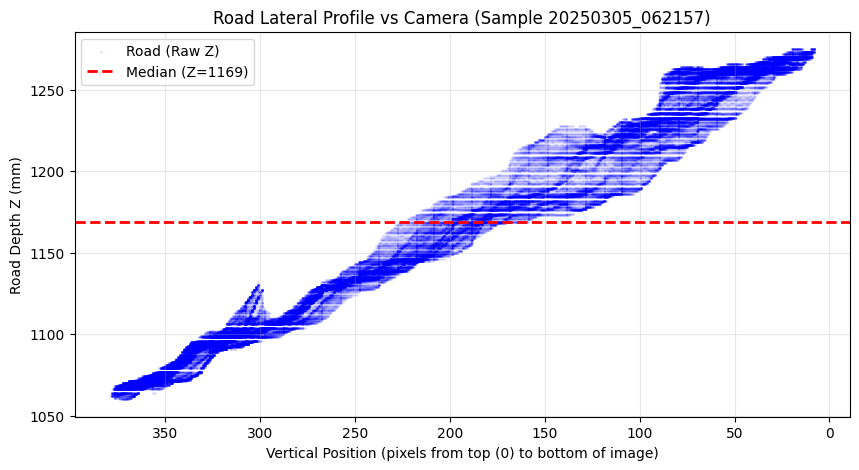

: 

In [ ]:
if depth is not None and mask is not None:
    # Selecionar apenas uma margem da rua limpa em volta do buraco (mas sem o buraco)
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (150, 150))
    expanded_mask = cv2.dilate((mask > 0).astype(np.uint8), kernel_large, iterations=1)
    road_only_mask = (expanded_mask > 0) & (mask == 0) & (depth > 0)
    
    # Extrair as coordenadas verticais (V) da imagem e os valores reais de Z
    h_img, w_img = depth.shape
    u_grid, v_grid = np.meshgrid(np.arange(w_img), np.arange(h_img))
    
    vertical_pixels = v_grid[road_only_mask]
    z_road_values = depth[road_only_mask].astype(np.float32)
    
    # Plotar o perfil de profundidade da rua
    plt.figure(figsize=(10, 5))
    plt.scatter(vertical_pixels, z_road_values, alpha=0.1, s=1, color='blue', label="Road (Raw Z)")
    
    # Plotar a nossa 'gambiarra' da mediana
    median_z = np.median(z_road_values)
    plt.axhline(median_z, color='red', linestyle='--', linewidth=2, label=f"Median (Z={median_z:.0f})")
    
    # Flip the X axis to mimic image view (0 at top, H at bottom)
    plt.gca().invert_xaxis()
    plt.title(f"Road Lateral Profile vs Camera (Sample {sample_id})")
    plt.xlabel("Vertical Position (pixels from top (0) to bottom of image)")
    plt.ylabel("Road Depth Z (mm)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Execute a célula de leitura de dados primeiro.")


Equação do Plano encontrada: 0.0020x + 0.2173y + 0.9761z + -1108.6540 = 0


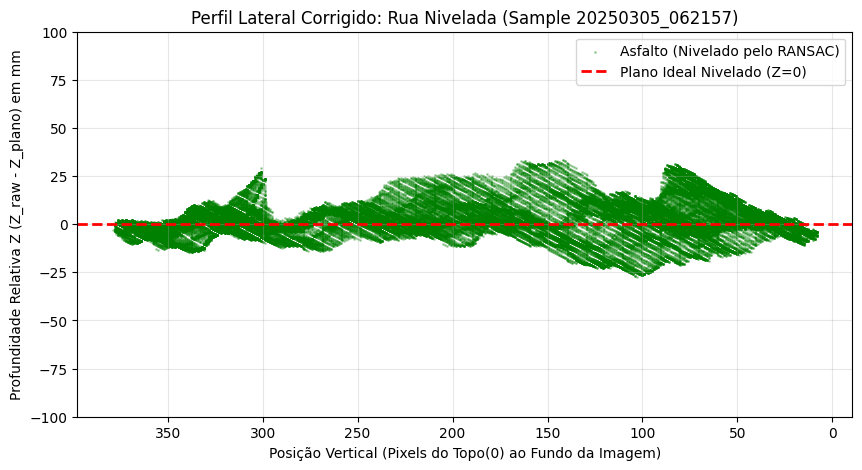

In [ ]:
if depth is not None and mask is not None:
    # 1. Preparar os pontos 3D apenas da rua para o Open3D
    road_X = (u_grid[road_only_mask] - cx) * z_road_values / fx
    road_Y = (v_grid[road_only_mask] - cy) * z_road_values / fy
    road_points_3d = np.stack((road_X, road_Y, z_road_values), axis=-1)

    pcd_road = o3d.geometry.PointCloud()
    pcd_road.points = o3d.utility.Vector3dVector(road_points_3d)

    # 2. RANSAC: Achar o Modelo do Plano (A*x + B*y + C*z + D = 0)
    # distance_threshold: margem de erro (10mm é razoável para a rugosidade do asfalto)
    plane_model, inliers = pcd_road.segment_plane(distance_threshold=10.0,
                                                  ransac_n=3,
                                                  num_iterations=1000)
    A, B, C, D = plane_model
    print(f"Equação do Plano encontrada: {A:.4f}x + {B:.4f}y + {C:.4f}z + {D:.4f} = 0")

    # 3. Calcular qual deveria ser a profundidade exata (Z_esperado) da rua para cada X e Y
    # C*z = -(A*x + B*y + D)  =>  z = -(A*x + B*y + D) / C
    z_expected_road = -(A * road_X + B * road_Y + D) / C
    
    # Ao invés de subtrair uma "mediana" estática, subtraímos a rampa exata daquele pixel!
    z_corrected_road = z_road_values - z_expected_road
    # 4. Plot the new corrected profile
    plt.figure(figsize=(10, 5))
    plt.scatter(vertical_pixels, z_corrected_road, alpha=0.3, s=1, color='green', label="Road (Leveled by RANSAC)")

    # The red line is now pinned at absolute 0
    plt.axhline(0, color='red', linestyle='--', linewidth=2, label="Ideal Leveled Plane (Z=0)")

    plt.gca().invert_xaxis()
    plt.title(f"Corrected Lateral Profile: Leveled Road (Sample {sample_id})")
    plt.xlabel("Vertical Position (pixels from top (0) to bottom of image)")
    plt.ylabel("Relative Depth Z (Z_raw - Z_plane) in mm")
    plt.ylim(-100, 100)  # Fix the scale to zoom in
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Execute a célula de leitura de dados primeiro.")
